In [ ]:
import pandas as pd

# Read data file
df = pd.read_csv("./data/customer_shopping_data.csv")

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [ ]:
# Review data structure
df.info()

# Review data summary
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB


,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [ ]:
# Check null data
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [ ]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Add new columns for data processing
df['Total_Revenue'] = df['quantity'] * df['price']
category_revenue = df.groupby('category')['Total_Revenue'].sum().sort_values(ascending=False).reset_index()
mall_revenue = df.groupby('shopping_mall')['Total_Revenue'].sum().sort_values(ascending=False).reset_index()
payment_gender = pd.crosstab(df['payment_method'], df['gender'])

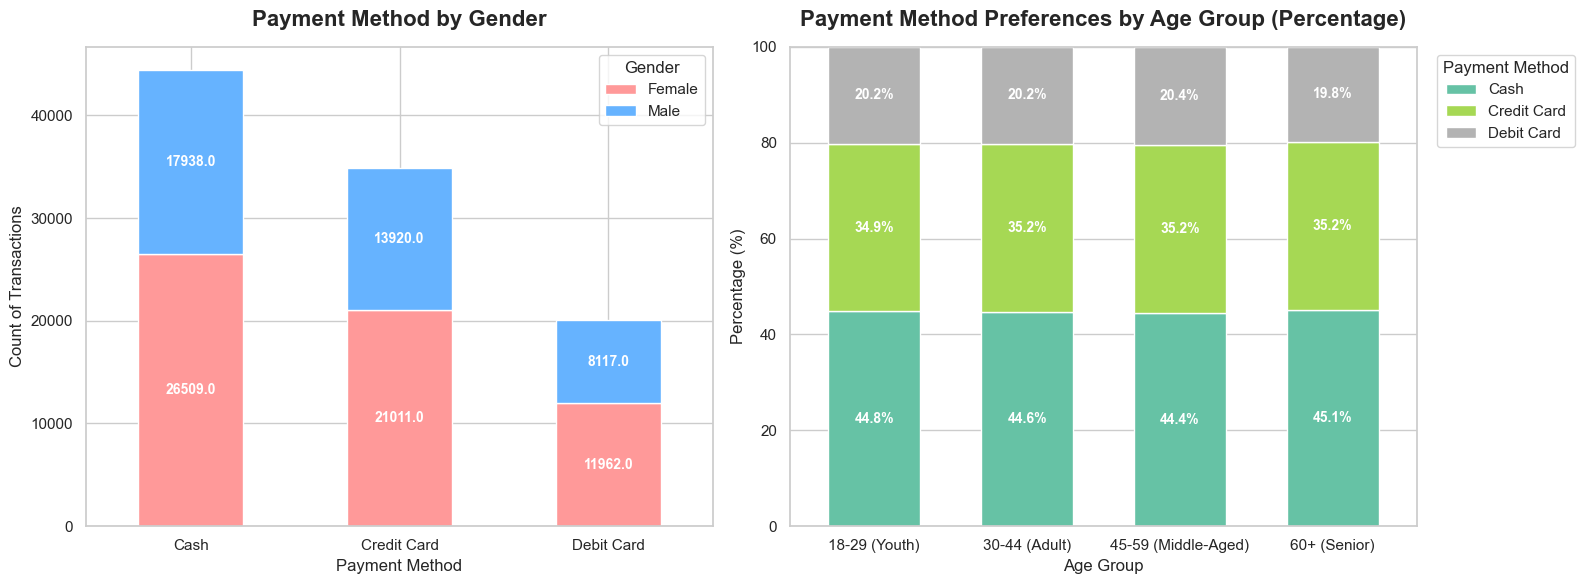

In [46]:
# Customer Analysis
f, ax = plt.subplots(1,2, figsize=(16, 6))
sns.set_theme(style="whitegrid")
# Payment Method by Gender
payment_gender.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax[0])
for container in ax[0].containers:
    # show the label
    labels = [f'{v.get_height()}' for v in container]
    # Put the label in the center of the bar
    ax[0].bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='white')
ax[0].set_title('Payment Method by Gender', fontsize=16, fontweight='bold', pad=15)
ax[0].set_xlabel('Payment Method')
ax[0].set_ylabel('Count of Transactions')
ax[0].tick_params(axis='x', rotation=0)
ax[0].legend(title='Gender')

# Different age groups
age_bins = [17, 29, 44, 59, 100]
age_labels = ['18-29 (Youth)', '30-44 (Adult)', '45-59 (Middle-Aged)', '60+ (Senior)']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Convert to percentage
payment_age = pd.crosstab(df['age_group'], df['payment_method'], normalize='index') * 100

# Payment preferences methond by age
payment_age.plot(kind='bar', stacked=True, cmap='Set2', width=0.6, ax=ax[1])
for container in ax[1].containers:
    # >1% then show the label
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 1 else '' for v in container]
    # Put the label in the center of the bar
    ax[1].bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='white')

ax[1].set_title('Payment Method Preferences by Age Group (Percentage)', fontsize=16, fontweight='bold', pad=15)
ax[1].set_xlabel('Age Group', fontsize=12)
ax[1].set_ylabel('Percentage (%)', fontsize=12)
ax[1].tick_params(axis='x', rotation=0)

# Move Legend to the outside of the chart, avoiding blocking the bars
ax[1].legend(title='Payment Method', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add percentage limit (0-100%)
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

Based on the visualizations, we can draw the following insights:
1. "Cash" is the most preferred payment method for both male and female customers, followed by "Credit Card" and "Debit Card." Furthermore, "Cash" consistently accounts for the highest percentage of payment preferences across all four age groups.
2. The dataset contains a higher volume of transactions from female customers compared to male customers.
3. There is no significant difference in payment method preferences across the different age groups, suggesting that payment behavior remains consistent regardless of age.

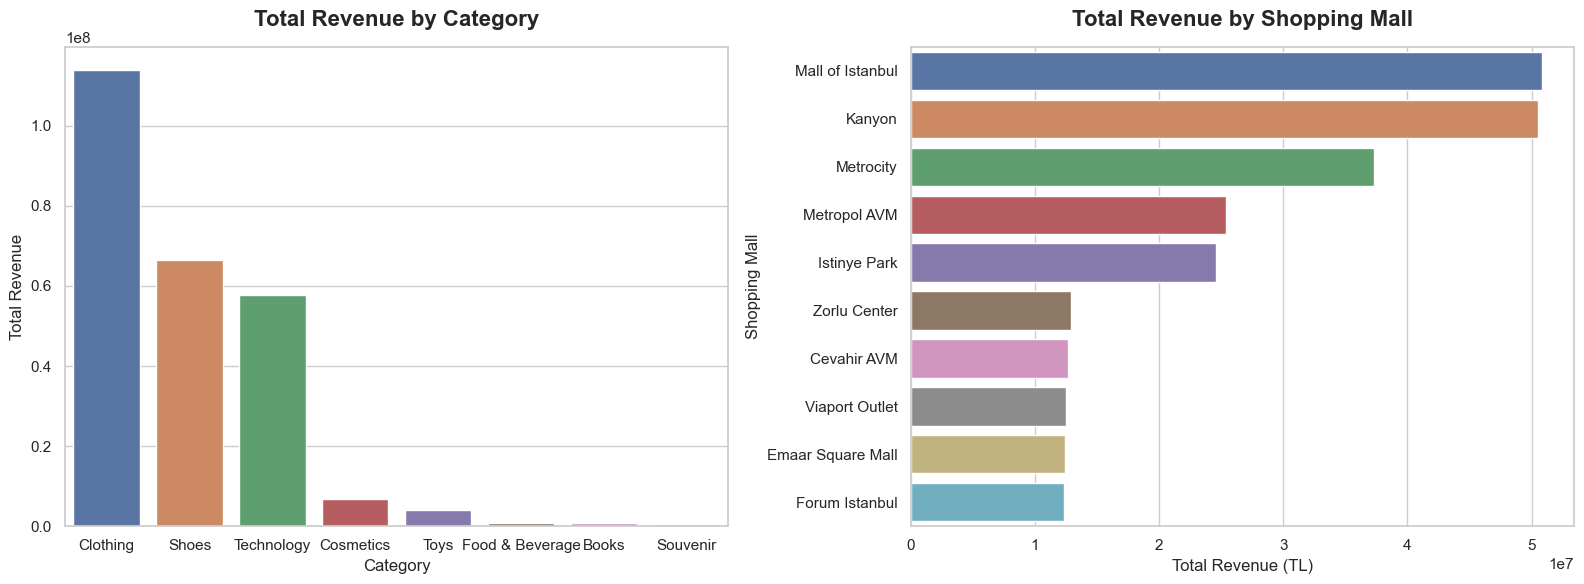

In [ ]:
#Revenue Hisgrams

#create a figure and a set of subplots 2X2
f, ax = plt.subplots(1,2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# category bar chart
sns.barplot(data=category_revenue, x='category', y='Total_Revenue', hue='category', legend=False, ax=ax[0])
ax[0].set_title('Total Revenue by Category', fontsize=16, fontweight='bold', pad=15)
ax[0].set_xlabel('Category')
ax[0].set_ylabel('Total Revenue')

#mall revenue bar chart
sns.barplot(x='Total_Revenue', y='shopping_mall', data=mall_revenue, hue='shopping_mall', legend=False, ax=ax[1])
ax[1].set_title('Total Revenue by Shopping Mall', fontsize=16, fontweight='bold', pad=15)
ax[1].set_xlabel('Total Revenue (TL)')
ax[1].set_ylabel('Shopping Mall')

plt.tight_layout()
plt.show()




Based on the visualizations, we can draw the following insights:
1. The "Clothing" category generates the highest revenue, closely followed by "Shoes" and "Technology." These three categories account for the vast majority of the company's total revenue.
2. Among all the listed shopping centers, the "Mall of Istanbul" brings in the highest revenue, with "Kanyon" shopping mall following slightly behind. Out of these ten shopping malls, five of them have generated over 2 million TL in revenue, and the top two have even surpassed the 5 million TL milestone.